In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "For variable coding (judgement ⑪), how accurately does each model fill the fixed 37-field schema — per-field, against Opus-coded gold — and which covariates are reliably codable at all?"

*Judgement ⑪ of 11 · Track B, step 2. The fields clustering runs on are only as good as this step. Numbers computed from the run.*

In [2]:

import json
from collections import defaultdict
from itertools import combinations

RUNS = json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j11_coding_runs.json", encoding="utf-8"))
MAN = RUNS["manifest"]
codings, gold_list, FIELDS = RUNS["codings"], RUNS["gold"], MAN["fields"]
CAND = MAN["candidate_models"]
PRICES = {'thinkingmachines/inkling': 1.0, 'openrouter/auto-beta': -1000000.0, 'moonshotai/kimi-k3': 3.0, 'meta/muse-spark-1.1': 1.25, 'kwaipilot/kat-coder-air-v2.5': 0.15, 'kwaipilot/kat-coder-pro-v2.5': 0.74, 'openai/gpt-5.6-luna-pro': 1.0, 'openai/gpt-5.6-luna': 1.0, 'openai/gpt-5.6-terra-pro': 2.5, 'openai/gpt-5.6-terra': 2.5, 'openai/gpt-5.6-sol-pro': 5.0, 'openai/gpt-5.6-sol': 5.0, 'x-ai/grok-4.5': 2.0, '~x-ai/grok-latest': 2.0, 'aion-labs/aion-3.0-mini': 0.7, 'aion-labs/aion-3.0': 3.0, 'tencent/hy3': 0.2, 'tencent/hy3:free': 0.0, 'poolside/laguna-xs-2.1': 0.06, 'poolside/laguna-xs-2.1:free': 0.0, 'anthropic/claude-sonnet-5': 2.0, 'google/gemini-3.1-flash-lite-image': 0.25, 'nex-agi/nex-n2-mini': 0.025, 'sakana/fugu-ultra': 5.0, 'google/gemini-3.1-flash-image': 0.5, 'google/gemini-3-pro-image': 2.0, 'cohere/north-mini-code:free': 0.0, 'z-ai/glm-5.2': 0.904, 'openrouter/fusion': -1000000.0, 'moonshotai/kimi-k2.7-code': 1.0, '~anthropic/claude-fable-latest': 10.0, 'anthropic/claude-fable-5': 10.0, 'nex-agi/nex-n2-pro': 0.25, 'nvidia/nemotron-3.5-content-safety:free': 0.0, 'nvidia/nemotron-3-ultra-550b-a55b': 0.6, 'nvidia/nemotron-3-ultra-550b-a55b:free': 0.0, 'qwen/qwen3.7-plus': 0.32, 'minimax/minimax-m3': 0.3, 'stepfun/step-3.7-flash': 0.2, 'anthropic/claude-opus-4.8-fast': 10.0, 'anthropic/claude-opus-4.8': 5.0, 'qwen/qwen3.7-max': 1.475, 'x-ai/grok-build-0.1': 1.0, 'google/gemini-3.5-flash': 1.5, 'anthropic/claude-opus-4.7-fast': 30.0, 'perceptron/perceptron-mk1': 0.15, 'inclusionai/ring-2.6-1t': 0.075, 'google/gemini-3.1-flash-lite': 0.25, 'openai/gpt-chat-latest': 5.0, 'x-ai/grok-4.3': 1.25, 'ibm-granite/granite-4.1-8b': 0.05, 'mistralai/mistral-medium-3-5': 1.5, 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free': 0.0, 'poolside/laguna-m.1': 0.2, 'poolside/laguna-m.1:free': 0.0, '~anthropic/claude-haiku-latest': 1.0, '~openai/gpt-mini-latest': 0.75, '~google/gemini-pro-latest': 2.0, '~moonshotai/kimi-latest': 3.0, '~google/gemini-flash-latest': 1.5, '~anthropic/claude-sonnet-latest': 2.0, '~openai/gpt-latest': 5.0, 'qwen/qwen3.5-plus-20260420': 0.3, 'qwen/qwen3.6-flash': 0.188, 'qwen/qwen3.6-35b-a3b': 0.14, 'qwen/qwen3.6-max-preview': 1.04, 'qwen/qwen3.6-27b': 0.45, 'openai/gpt-5.5-pro': 30.0, 'openai/gpt-5.5': 5.0, 'deepseek/deepseek-v4-pro': 0.435, 'deepseek/deepseek-v4-flash': 0.098, 'inclusionai/ling-2.6-1t': 0.075, 'tencent/hy3-preview': 0.063, 'xiaomi/mimo-v2.5-pro': 0.435, 'xiaomi/mimo-v2.5': 0.14, 'openai/gpt-5.4-image-2': 8.0, 'inclusionai/ling-2.6-flash': 0.01, '~anthropic/claude-opus-latest': 5.0, 'openrouter/pareto-code': -1000000.0, 'moonshotai/kimi-k2.6': 0.95, 'anthropic/claude-opus-4.7': 5.0, 'z-ai/glm-5.1': 0.966, 'google/gemma-4-26b-a4b-it': 0.1, 'google/gemma-4-26b-a4b-it:free': 0.0, 'google/gemma-4-31b-it': 0.22, 'google/gemma-4-31b-it:free': 0.0, 'qwen/qwen3.6-plus': 0.325, 'z-ai/glm-5v-turbo': 1.2, 'arcee-ai/trinity-large-thinking': 0.25, 'x-ai/grok-4.20-multi-agent': 1.25, 'x-ai/grok-4.20': 1.25, 'google/lyria-3-pro-preview': 0.0, 'google/lyria-3-clip-preview': 0.0, 'kwaipilot/kat-coder-pro-v2': 0.3, 'rekaai/reka-edge': 0.1, 'minimax/minimax-m2.7': 0.25, 'openai/gpt-5.4-nano': 0.2, 'openai/gpt-5.4-mini': 0.75, 'mistralai/mistral-small-2603': 0.15, 'z-ai/glm-5-turbo': 1.2, 'nvidia/nemotron-3-super-120b-a12b': 0.21, 'nvidia/nemotron-3-super-120b-a12b:free': 0.0, 'bytedance-seed/seed-2.0-lite': 0.25, 'qwen/qwen3.5-9b': 0.1, 'openai/gpt-5.4-pro': 30.0, 'openai/gpt-5.4': 2.5, 'inception/mercury-2': 0.25, 'openai/gpt-5.3-chat': 1.75, 'google/gemini-3.1-flash-lite-preview': 0.25, 'bytedance-seed/seed-2.0-mini': 0.1, 'google/gemini-3.1-flash-image-preview': 0.5, 'qwen/qwen3.5-35b-a3b': 0.14, 'qwen/qwen3.5-27b': 0.26, 'qwen/qwen3.5-122b-a10b': 0.26, 'qwen/qwen3.5-flash-02-23': 0.065, 'google/gemini-3.1-pro-preview-customtools': 2.0, 'openai/gpt-5.3-codex': 1.75, 'aion-labs/aion-2.0': 0.8, 'google/gemini-3.1-pro-preview': 2.0, 'anthropic/claude-sonnet-4.6': 3.0, 'qwen/qwen3.5-plus-02-15': 0.26, 'qwen/qwen3.5-397b-a17b': 0.39, 'minimax/minimax-m2.5': 0.15, 'z-ai/glm-5': 0.95, 'qwen/qwen3-max-thinking': 0.78, 'anthropic/claude-opus-4.6': 5.0, 'qwen/qwen3-coder-next': 0.11, 'openrouter/free': 0.0, 'stepfun/step-3.5-flash': 0.1, 'moonshotai/kimi-k2.5': 0.57, 'upstage/solar-pro-3': 0.15, 'minimax/minimax-m2-her': 0.3, 'writer/palmyra-x5': 0.6, 'openai/gpt-audio': 2.5, 'openai/gpt-audio-mini': 0.6, 'z-ai/glm-4.7-flash': 0.061, 'openai/gpt-5.2-codex': 1.75, 'bytedance-seed/seed-1.6-flash': 0.075, 'bytedance-seed/seed-1.6': 0.25, 'minimax/minimax-m2.1': 0.3, 'z-ai/glm-4.7': 0.4, 'google/gemini-3-flash-preview': 0.5, 'nvidia/nemotron-3-nano-30b-a3b': 0.05, 'nvidia/nemotron-3-nano-30b-a3b:free': 0.0, 'openai/gpt-5.2-chat': 1.75, 'openai/gpt-5.2-pro': 21.0, 'openai/gpt-5.2': 1.75, 'mistralai/devstral-2512': 0.4, 'relace/relace-search': 1.0, 'z-ai/glm-4.6v': 0.3, 'openrouter/bodybuilder': -1000000.0, 'openai/gpt-5.1-codex-max': 1.25, 'amazon/nova-2-lite-v1': 0.3, 'mistralai/ministral-14b-2512': 0.2, 'mistralai/ministral-8b-2512': 0.15, 'mistralai/ministral-3b-2512': 0.1, 'mistralai/mistral-large-2512': 0.5, 'deepseek/deepseek-v3.2': 0.269, 'anthropic/claude-opus-4.5': 5.0, 'allenai/olmo-3-32b-think': 0.15, 'google/gemini-3-pro-image-preview': 2.0, 'deepcogito/cogito-v2.1-671b': 1.25, 'openai/gpt-5.1': 1.25, 'openai/gpt-5.1-chat': 1.25, 'openai/gpt-5.1-codex': 1.25, 'openai/gpt-5.1-codex-mini': 0.25, 'moonshotai/kimi-k2-thinking': 0.6, 'amazon/nova-premier-v1': 2.5, 'perplexity/sonar-pro-search': 3.0, 'mistralai/voxtral-small-24b-2507': 0.1, 'openai/gpt-oss-safeguard-20b': 0.075, 'nvidia/nemotron-nano-12b-v2-vl:free': 0.0, 'minimax/minimax-m2': 0.255, 'qwen/qwen3-vl-32b-instruct': 0.104, 'ibm-granite/granite-4.0-h-micro': 0.017, 'openai/gpt-5-image-mini': 2.5, 'anthropic/claude-haiku-4.5': 1.0, 'qwen/qwen3-vl-8b-thinking': 0.117, 'qwen/qwen3-vl-8b-instruct': 0.117, 'openai/gpt-5-image': 10.0, 'openai/o3-deep-research': 10.0, 'openai/o4-mini-deep-research': 2.0, 'google/gemini-2.5-flash-image': 0.3, 'qwen/qwen3-vl-30b-a3b-thinking': 0.13, 'qwen/qwen3-vl-30b-a3b-instruct': 0.13, 'openai/gpt-5-pro': 15.0, 'z-ai/glm-4.6': 0.5, 'anthropic/claude-sonnet-4.5': 3.0, 'deepseek/deepseek-v3.2-exp': 0.27, 'thedrummer/cydonia-24b-v4.1': 0.3, 'relace/relace-apply-3': 0.85, 'qwen/qwen3-vl-235b-a22b-thinking': 0.26, 'qwen/qwen3-vl-235b-a22b-instruct': 0.21, 'qwen/qwen3-max': 0.78, 'qwen/qwen3-coder-plus': 0.65, 'openai/gpt-5-codex': 1.25, 'deepseek/deepseek-v3.1-terminus': 0.27, 'qwen/qwen3-coder-flash': 0.195, 'qwen/qwen3-next-80b-a3b-thinking': 0.098, 'qwen/qwen3-next-80b-a3b-instruct': 0.1, 'qwen/qwen3-next-80b-a3b-instruct:free': 0.0, 'qwen/qwen-plus-2025-07-28': 0.26, 'qwen/qwen-plus-2025-07-28:thinking': 0.26, 'nvidia/nemotron-nano-9b-v2:free': 0.0, 'moonshotai/kimi-k2-0905': 0.6, 'qwen/qwen3-30b-a3b-thinking-2507': 0.13, 'nousresearch/hermes-4-70b': 0.13, 'nousresearch/hermes-4-405b': 1.0, 'deepseek/deepseek-chat-v3.1': 0.25, 'mistralai/mistral-medium-3.1': 0.4, 'z-ai/glm-4.5v': 0.6, 'ai21/jamba-large-1.7': 2.0, 'openai/gpt-5-chat': 1.25, 'openai/gpt-5': 1.25, 'openai/gpt-5-mini': 0.25, 'openai/gpt-5-nano': 0.05, 'openai/gpt-oss-120b': 0.037, 'openai/gpt-oss-20b': 0.03, 'openai/gpt-oss-20b:free': 0.0, 'anthropic/claude-opus-4.1': 15.0, 'mistralai/codestral-2508': 0.3, 'qwen/qwen3-coder-30b-a3b-instruct': 0.07, 'qwen/qwen3-30b-a3b-instruct-2507': 0.1, 'z-ai/glm-4.5': 0.6, 'z-ai/glm-4.5-air': 0.13, 'qwen/qwen3-235b-a22b-thinking-2507': 0.15, 'qwen/qwen3-coder': 0.3, 'qwen/qwen3-coder:free': 0.0, 'bytedance/ui-tars-1.5-7b': 0.1, 'google/gemini-2.5-flash-lite': 0.1, 'qwen/qwen3-235b-a22b-2507': 0.09, 'moonshotai/kimi-k2': 0.57, 'cognitivecomputations/dolphin-mistral-24b-venice-edition': 0.2, 'cognitivecomputations/dolphin-mistral-24b-venice-edition:free': 0.0, 'tencent/hunyuan-a13b-instruct': 0.14, 'morph/morph-v3-large': 0.9, 'morph/morph-v3-fast': 0.8, 'baidu/ernie-4.5-vl-424b-a47b': 0.42, 'mistralai/mistral-small-3.2-24b-instruct': 0.1, 'minimax/minimax-m1': 0.55, 'google/gemini-2.5-flash': 0.3, 'google/gemini-2.5-pro': 1.25, 'openai/o3-pro': 20.0, 'google/gemini-2.5-pro-preview': 1.25, 'deepseek/deepseek-r1-0528': 0.5, 'anthropic/claude-opus-4': 15.0, 'anthropic/claude-sonnet-4': 3.0, 'google/gemma-3n-e4b-it': 0.06, 'mistralai/mistral-medium-3': 0.4, 'google/gemini-2.5-pro-preview-05-06': 1.25, 'arcee-ai/virtuoso-large': 0.75, 'meta-llama/llama-guard-4-12b': 0.18, 'qwen/qwen3-30b-a3b': 0.13, 'qwen/qwen3-8b': 0.117, 'qwen/qwen3-14b': 0.12, 'qwen/qwen3-32b': 0.08, 'qwen/qwen3-235b-a22b': 0.455, 'openai/o4-mini-high': 1.1, 'openai/o3': 2.0, 'openai/o4-mini': 1.1, 'openai/gpt-4.1': 2.0, 'openai/gpt-4.1-mini': 0.4, 'openai/gpt-4.1-nano': 0.1, 'meta-llama/llama-4-maverick': 0.2, 'meta-llama/llama-4-scout': 0.1, 'deepseek/deepseek-chat-v3-0324': 0.27, 'openai/o1-pro': 150.0, 'mistralai/mistral-small-3.1-24b-instruct': 0.351, 'google/gemma-3-4b-it': 0.05, 'google/gemma-3-12b-it': 0.05, 'cohere/command-a': 2.5, 'openai/gpt-4o-mini-search-preview': 0.15, 'openai/gpt-4o-search-preview': 2.5, 'rekaai/reka-flash-3': 0.1, 'google/gemma-3-27b-it': 0.1, 'thedrummer/skyfall-36b-v2': 0.55, 'perplexity/sonar-reasoning-pro': 2.0, 'perplexity/sonar-pro': 3.0, 'perplexity/sonar-deep-research': 2.0, 'mistralai/mistral-saba': 0.2, 'openai/o3-mini-high': 1.1, 'aion-labs/aion-rp-llama-3.1-8b': 0.8, 'qwen/qwen2.5-vl-72b-instruct': 0.8, 'qwen/qwen-plus': 0.26, 'openai/o3-mini': 1.1, 'mistralai/mistral-small-24b-instruct-2501': 0.05, 'perplexity/sonar': 1.0, 'deepseek/deepseek-r1-distill-llama-70b': 0.8, 'deepseek/deepseek-r1': 0.7, 'minimax/minimax-01': 0.2, 'microsoft/phi-4': 0.07, 'deepseek/deepseek-chat': 0.2, 'sao10k/l3.3-euryale-70b': 0.65, 'openai/o1': 15.0, 'cohere/command-r7b-12-2024': 0.037, 'meta-llama/llama-3.3-70b-instruct': 0.13, 'meta-llama/llama-3.3-70b-instruct:free': 0.0, 'amazon/nova-lite-v1': 0.06, 'amazon/nova-micro-v1': 0.035, 'amazon/nova-pro-v1': 0.8, 'openai/gpt-4o-2024-11-20': 2.5, 'mistralai/mistral-large-2407': 2.0, 'qwen/qwen-2.5-coder-32b-instruct': 0.66, 'thedrummer/unslopnemo-12b': 0.4, 'anthracite-org/magnum-v4-72b': 3.0, 'qwen/qwen-2.5-7b-instruct': 0.04, 'inflection/inflection-3-pi': 2.5, 'inflection/inflection-3-productivity': 2.5, 'thedrummer/rocinante-12b': 0.25, 'meta-llama/llama-3.2-1b-instruct': 0.027, 'meta-llama/llama-3.2-3b-instruct': 0.051, 'meta-llama/llama-3.2-3b-instruct:free': 0.0, 'qwen/qwen-2.5-72b-instruct': 0.36, 'cohere/command-r-08-2024': 0.15, 'cohere/command-r-plus-08-2024': 2.5, 'sao10k/l3.1-euryale-70b': 0.85, 'nousresearch/hermes-3-llama-3.1-70b': 0.7, 'nousresearch/hermes-3-llama-3.1-405b': 1.0, 'nousresearch/hermes-3-llama-3.1-405b:free': 0.0, 'sao10k/l3-lunaris-8b': 0.04, 'openai/gpt-4o-2024-08-06': 2.5, 'meta-llama/llama-3.1-70b-instruct': 0.4, 'meta-llama/llama-3.1-8b-instruct': 0.05, 'mistralai/mistral-nemo': 0.019, 'openai/gpt-4o-mini': 0.15, 'openai/gpt-4o-mini-2024-07-18': 0.15, 'google/gemma-2-27b-it': 0.65, 'openai/gpt-4o': 2.5, 'openai/gpt-4o-2024-05-13': 5.0, 'mistralai/mixtral-8x22b-instruct': 2.0, 'microsoft/wizardlm-2-8x22b': 0.62, 'openai/gpt-4-turbo': 10.0, 'anthropic/claude-3-haiku': 0.25, 'mistralai/mistral-large': 2.0, 'openai/gpt-3.5-turbo-0613': 1.0, 'openai/gpt-4-turbo-preview': 10.0, 'openrouter/auto': -1000000.0, 'openai/gpt-3.5-turbo-instruct': 1.5, 'openai/gpt-3.5-turbo-16k': 3.0, 'mancer/weaver': 0.5, 'undi95/remm-slerp-l2-13b': 0.45, 'gryphe/mythomax-l2-13b': 0.06, 'openai/gpt-3.5-turbo': 0.5, 'openai/gpt-4': 30.0}
def short(m): return m.split("/")[-1]
GOLD = {g["sample_id"]: g["fields"] for g in gold_list}
SAMPLES = sorted(GOLD)

def jacc(a, b):
    a, b = set(a or []), set(b or [])
    return len(a & b) / len(a | b) if (a | b) else 1.0

cod = defaultdict(dict)
for c in codings:
    cod[c["model"]][c["sample_id"]] = c["fields"]

VAL_TAU = 0.3  # value-set overlap needed to count a co-populated field as value-correct

# per-model presence P/R/F1, value agreement, and strict field-F1 (present + value agrees)
mr = []
field_stat = {f: dict(tp=0, fp=0, fn=0, vj=[]) for f in FIELDS}
for m in CAND:
    tp = fp = fn = 0; vjac = []; strict_correct = 0
    for s in SAMPLES:
        gf, mf = GOLD.get(s, {}), cod[m].get(s, {})
        for f in FIELDS:
            gp, mp = bool(gf.get(f)), bool(mf.get(f))
            if gp and mp:
                tp += 1; vj = jacc(mf.get(f), gf.get(f)); vjac.append(vj)
                if vj >= VAL_TAU: strict_correct += 1
                field_stat[f]["tp"] += 1; field_stat[f]["vj"].append(vj)
            elif gp and not mp:
                fn += 1; field_stat[f]["fn"] += 1
            elif mp and not gp:
                fp += 1; field_stat[f]["fp"] += 1
    prec = tp / (tp + fp) if (tp + fp) else np.nan
    rec = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = 2 * prec * rec / (prec + rec) if (prec and rec) else np.nan
    # strict F1 (presence AND value agreement)
    sprec = strict_correct / (tp + fp) if (tp + fp) else np.nan
    srec = strict_correct / (tp + fn) if (tp + fn) else np.nan
    sf1 = 2 * sprec * srec / (sprec + srec) if (sprec and srec) else np.nan
    mr.append(dict(model=m, mshort=short(m), presence_f1=f1, precision=prec, recall=rec,
                   value_acc=(np.mean(vjac) if vjac else np.nan), strict_f1=sf1,
                   n_populated=tp + fp, price=PRICES.get(m, np.nan)))
MS = pd.DataFrame(mr)
FAILED = MS[MS.n_populated == 0].mshort.tolist()
MS = MS[MS.n_populated > 0].reset_index(drop=True)

# per-field codability (presence F1 pooled across models + mean value agreement)
fr = []
for f in FIELDS:
    st = field_stat[f]
    p = st["tp"] / (st["tp"] + st["fp"]) if (st["tp"] + st["fp"]) else np.nan
    r = st["tp"] / (st["tp"] + st["fn"]) if (st["tp"] + st["fn"]) else np.nan
    f1 = 2 * p * r / (p + r) if (p and r) else np.nan
    fr.append(dict(field=f, presence_f1=f1, value_acc=(np.mean(st["vj"]) if st["vj"] else np.nan),
                   gold_freq=st["tp"] + st["fn"]))
FS = pd.DataFrame(fr)

_best = MS.sort_values("strict_f1", ascending=False).iloc[0]
_hard = FS[FS.gold_freq >= 3].sort_values("presence_f1").head(3)
_easy = FS[FS.gold_freq >= 3].sort_values("presence_f1", ascending=False).head(3)
display(Markdown(f"""
**Abstract.** Variable coding (judgement ⑪) fills the fixed **{len(FIELDS)}-field** schema with values —
the covariates clustering actually runs on. We score each of **{len(MS)} models** on {MAN['n_posts']} posts
against **Opus-coded gold**, per field, on presence (did it populate the field iff Opus did) and value
agreement (overlap of the values). **{_best.mshort}** codes best (strict F1={_best.strict_f1:.2f}, counting a
field correct only when it is both populated and its values overlap gold). But the sharper finding is
per-field: some covariates are reliably codable — **{', '.join(_easy.field)}** — while others are near-
unusable no matter the model — **{', '.join(_hard.field)}** — which tells clustering which axes to trust and
which to drop.{(' No parseable codings from: ' + ', '.join(FAILED) + '.') if FAILED else ''}
"""))



**Abstract.** Variable coding (judgement ⑪) fills the fixed **37-field** schema with values —
the covariates clustering actually runs on. We score each of **22 models** on 30 posts
against **Opus-coded gold**, per field, on presence (did it populate the field iff Opus did) and value
agreement (overlap of the values). **gemini-3.5-flash** codes best (strict F1=0.37, counting a
field correct only when it is both populated and its values overlap gold). But the sharper finding is
per-field: some covariates are reliably codable — **clinical_trial_participation, conditions, biomarker_results** — while others are near-
unusable no matter the model — **dosage, misdiagnosis, healthcare_system** — which tells clustering which axes to trust and
which to drop.


## 1. What this judgement is, and why it's load-bearing

`llm_extract.py` reads a post and fills the fixed schema — `age`, `conditions`, `functional_status_tier`, `treatment_outcome`, and 33 others. These *are* the clustering covariates: a mis-coded or missing value is a corrupt or absent feature. Because the schema is fixed and the source text is given, this is factual — scored per field against an Opus-coded gold, on whether the model populates the right fields (presence) and gets the right values.

## 2. Correctness scorecard

Per model, three numbers: **presence F1** (did it populate the fields Opus did?), **value agreement** (when both populate a field, do the values overlap?), and **strict F1** (a field counts only if populated *and* values agree). Strict F1 is the headline — it penalises both missing a field and filling it with the wrong value.

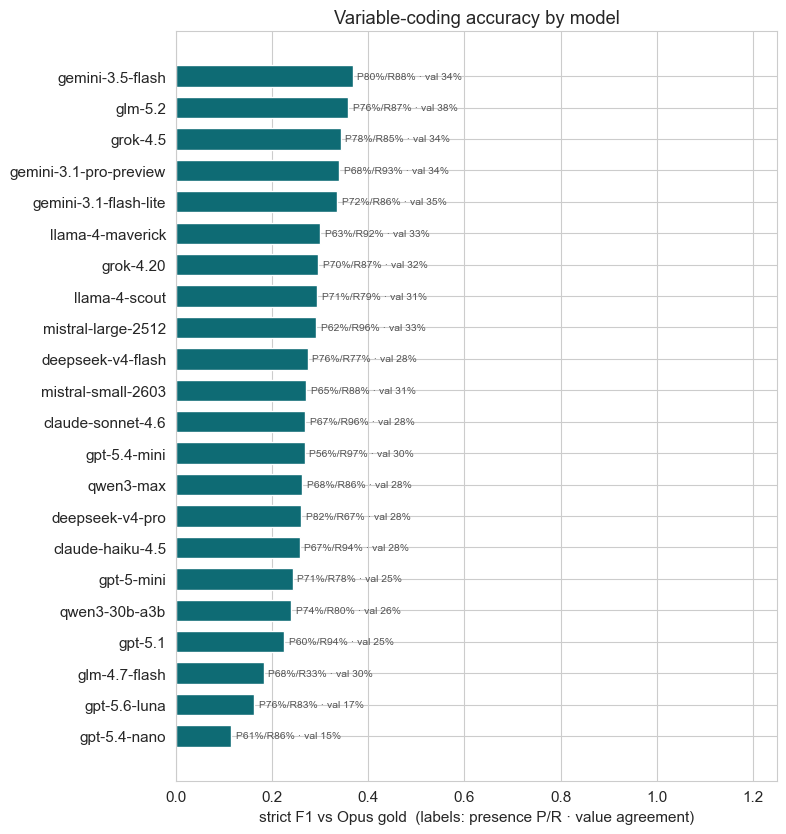

model,strict F1,presence F1,precision,recall,value agree,$/1M in
gemini-3.5-flash,0.37,0.84,80%,88%,34%,$1.5
glm-5.2,0.36,0.81,76%,87%,38%,$0.904
grok-4.5,0.34,0.81,78%,85%,34%,$2
gemini-3.1-pro-preview,0.34,0.78,68%,93%,34%,$2
gemini-3.1-flash-lite,0.33,0.78,72%,86%,35%,$0.25
llama-4-maverick,0.30,0.75,63%,92%,33%,$0.2
grok-4.20,0.30,0.77,70%,87%,32%,$1.25
llama-4-scout,0.29,0.75,71%,79%,31%,$0.1
mistral-large-2512,0.29,0.75,62%,96%,33%,$0.5
deepseek-v4-flash,0.27,0.77,76%,77%,28%,$0.098


In [3]:

d = MS.sort_values("strict_f1")
fig, ax = plt.subplots(figsize=(8, 0.34*len(d) + 1))
ax.barh(d.mshort, d.strict_f1, color="#0e6b74", height=0.68)
for y, (_, r) in enumerate(d.iterrows()):
    ax.text(r.strict_f1 + 0.01, y, f"P{r.precision:.0%}/R{r.recall:.0%} · val {r.value_acc:.0%}", va="center", fontsize=7.5, color="#555")
ax.set_xlim(0, 1.25); ax.set_xlabel("strict F1 vs Opus gold  (labels: presence P/R · value agreement)")
ax.set_title("Variable-coding accuracy by model"); fig.tight_layout(); plt.show()
tbl = MS.sort_values("strict_f1", ascending=False)[["mshort","strict_f1","presence_f1","precision","recall","value_acc","price"]].copy()
for c in ["strict_f1","presence_f1"]: tbl[c] = tbl[c].round(2)
for c in ["precision","recall","value_acc"]: tbl[c] = (tbl[c]*100).round(0).astype("Int64").astype(str)+"%"
tbl["price"] = tbl["price"].map(lambda v: f"${v:g}" if pd.notna(v) else "?")
tbl.columns = ["model","strict F1","presence F1","precision","recall","value agree","$/1M in"]
display(HTML("<b>Per-model coding accuracy</b>" + tbl.to_html(index=False)))


## 3. The real finding — which covariates are codable

Model choice matters less than *field* choice. Pooled across the roster, each field has its own codability: some are extracted reliably, others fail for everyone. A field no model can code is a clustering axis to drop, regardless of which model runs production.

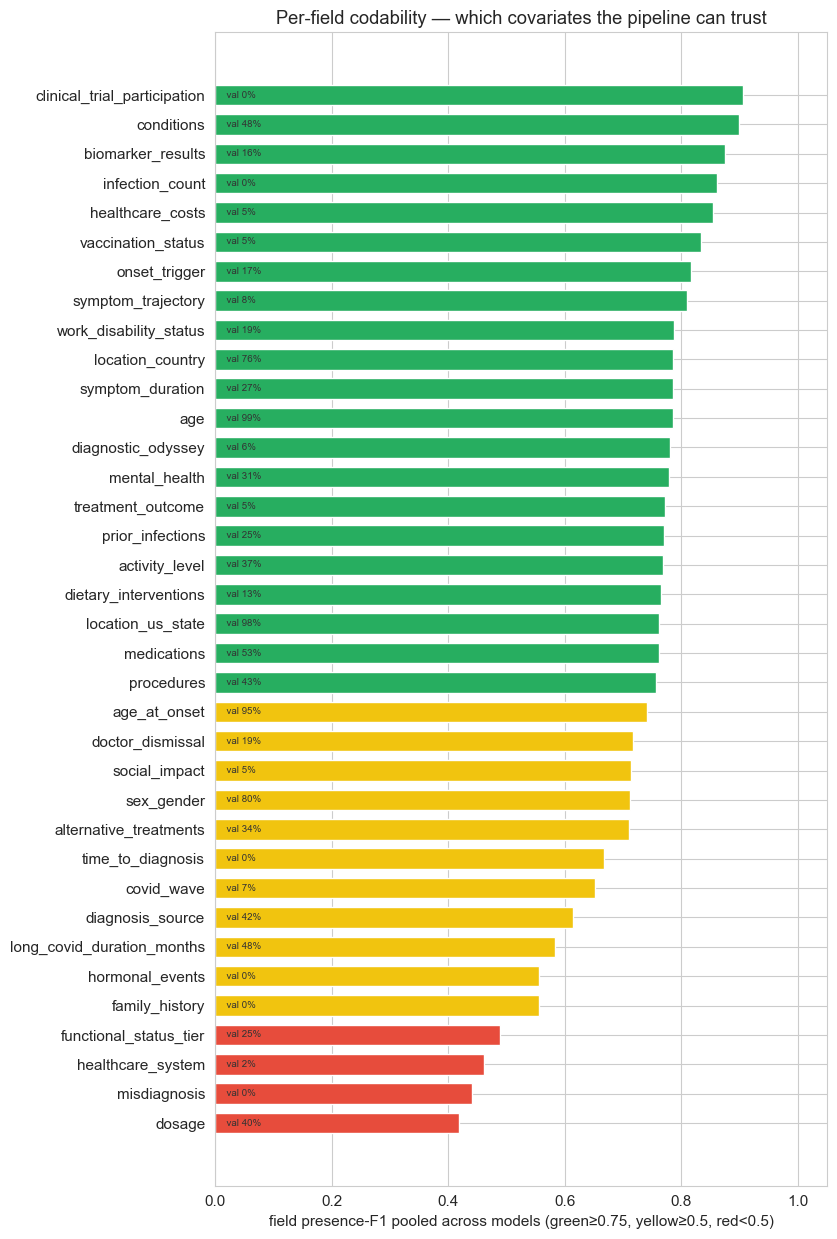

**What this shows:** of 37 schema fields, **21** are coded reliably (F1≥0.75) and **4** are near-unusable (F1<0.5) — e.g. dosage, misdiagnosis, healthcare_system, functional_status_tier. And presence is the easy part: even on fields both populate, mean value agreement is only **29%**, so the *values* drift further than the field-presence numbers suggest.

In [4]:

d = FS[FS.gold_freq >= 2].sort_values("presence_f1")
fig, ax = plt.subplots(figsize=(8.5, 0.32*len(d) + 1))
colors = ["#e74c3c" if v < 0.5 else "#f1c40f" if v < 0.75 else "#27ae60" for v in d.presence_f1.fillna(0)]
ax.barh(d.field, d.presence_f1.fillna(0), color=colors, height=0.7)
for y, (_, r) in enumerate(d.iterrows()):
    ax.text(0.01, y, f"  val {r.value_acc:.0%}" if pd.notna(r.value_acc) else "", va="center", fontsize=7, color="#333")
ax.set_xlim(0, 1.05); ax.set_xlabel("field presence-F1 pooled across models (green≥0.75, yellow≥0.5, red<0.5)")
ax.set_title("Per-field codability — which covariates the pipeline can trust"); fig.tight_layout(); plt.show()
red = d[d.presence_f1 < 0.5]
display(Markdown(
  f"**What this shows:** of {len(FS)} schema fields, **{int((FS.presence_f1>=0.75).sum())}** are coded reliably "
  f"(F1≥0.75) and **{len(red)}** are near-unusable (F1<0.5) — e.g. {', '.join(red.field.head(4))}. And presence "
  f"is the easy part: even on fields both populate, mean value agreement is only "
  f"**{FS.value_acc.mean():.0%}**, so the *values* drift further than the field-presence numbers suggest."))


## 4. Counterintuitive: presence is easy, values are hard — and models split eager vs cautious

A model can populate the right fields yet fill them with subtly wrong values, so the presence numbers flatter the real accuracy. And as in drug-ID, models sit on a precision–recall tradeoff — some over-populate (fill fields Opus left null), some under-populate (miss fields Opus found).

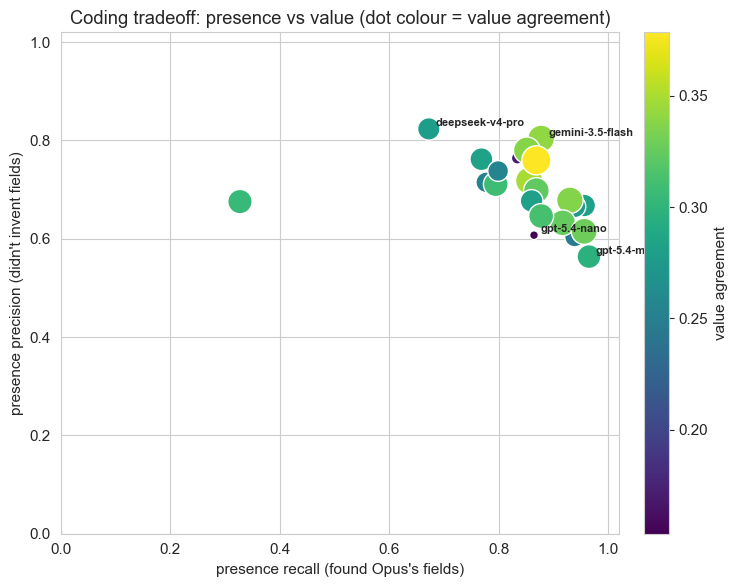

**What this shows:** the most thorough is **gpt-5.4-mini** (97% recall), the most conservative **deepseek-v4-pro** (82% precision). But note the colour: even top presence models carry value agreement around 30% — populating the field is not the same as coding it right, and clustering consumes the *value*, not the presence.

In [5]:

fig, ax = plt.subplots(figsize=(7.5, 6))
sizes = 40 + 400*(MS.value_acc.fillna(0) - MS.value_acc.min())/(MS.value_acc.max()-MS.value_acc.min()+1e-9)
sc = ax.scatter(MS.recall, MS.precision, s=sizes, c=MS.value_acc, cmap="viridis", zorder=3, edgecolor="white")
for i in {MS.precision.idxmax(), MS.recall.idxmax(), MS.strict_f1.idxmax(), MS.strict_f1.idxmin()}:
    r = MS.loc[i]; ax.annotate(r.mshort, (r.recall, r.precision), fontsize=8, fontweight="bold", xytext=(5,2), textcoords="offset points")
ax.set_xlabel("presence recall (found Opus's fields)"); ax.set_ylabel("presence precision (didn't invent fields)")
ax.set_xlim(0,1.02); ax.set_ylim(0,1.02); fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="value agreement")
ax.set_title("Coding tradeoff: presence vs value (dot colour = value agreement)")
fig.tight_layout(); plt.show()
display(Markdown(
  f"**What this shows:** the most thorough is **{MS.sort_values('recall',ascending=False).iloc[0].mshort}** "
  f"({MS.recall.max():.0%} recall), the most conservative **{MS.sort_values('precision',ascending=False).iloc[0].mshort}** "
  f"({MS.precision.max():.0%} precision). But note the colour: even top presence models carry value agreement "
  f"around {MS.value_acc.median():.0%} — populating the field is not the same as coding it right, and clustering "
  f"consumes the *value*, not the presence."))


## 5. Conclusion & scorecard — coding accuracy per dollar

The scorecard, and the design's payoff for the covariate step.

In [6]:

best = MS.strict_f1.max()
elig = MS[MS.strict_f1 >= best - 0.05]
pick = elig.sort_values("price").iloc[0] if elig.price.notna().any() else MS.sort_values("strict_f1", ascending=False).iloc[0]
sc = MS.sort_values("strict_f1", ascending=False)[["mshort","strict_f1","presence_f1","value_acc","precision","recall","price"]].copy()
for c in ["strict_f1","presence_f1"]: sc[c] = sc[c].round(2)
for c in ["value_acc","precision","recall"]: sc[c] = (sc[c]*100).round(0).astype("Int64").astype(str)+"%"
sc["price"] = sc["price"].map(lambda v: f"${v:g}" if pd.notna(v) else "?")
sc.columns = ["model","strict F1","presence F1","value agree","precision","recall","$/1M in"]
display(HTML("<b>⑪ coding — full scorecard</b>" + sc.to_html(index=False)))
n_reliable = int((FS.presence_f1>=0.75).sum()); n_bad = int((FS.presence_f1<0.5).sum())
lines = [
  f"- **Best coder:** {MS.sort_values('strict_f1',ascending=False).iloc[0].mshort} (strict F1 {best:.2f}).",
  f"- **Best value:** **{pick.mshort}** — strict F1 {pick.strict_f1:.2f} at ${pick.price:g}/1M input"
  + (", within 5 points of the best while cheaper." if pick.strict_f1 < best else "."),
  f"- **Trust the field, not just the model:** {n_reliable} of {len(FS)} covariates code reliably (F1≥0.75); "
  f"{n_bad} are near-unusable (F1<0.5) and should be dropped or hand-audited before clustering — this holds "
  f"across every model.",
  f"- **Values drift more than presence** (mean value agreement {MS.value_acc.mean():.0%}), so even a good "
  f"presence-F1 needs the value check before a covariate is trusted.",
]
display(Markdown("### Verdict\n\n" + "\n".join(lines)))


model,strict F1,presence F1,value agree,precision,recall,$/1M in
gemini-3.5-flash,0.37,0.84,34%,80%,88%,$1.5
glm-5.2,0.36,0.81,38%,76%,87%,$0.904
grok-4.5,0.34,0.81,34%,78%,85%,$2
gemini-3.1-pro-preview,0.34,0.78,34%,68%,93%,$2
gemini-3.1-flash-lite,0.33,0.78,35%,72%,86%,$0.25
llama-4-maverick,0.30,0.75,33%,63%,92%,$0.2
grok-4.20,0.30,0.77,32%,70%,87%,$1.25
llama-4-scout,0.29,0.75,31%,71%,79%,$0.1
mistral-large-2512,0.29,0.75,33%,62%,96%,$0.5
deepseek-v4-flash,0.27,0.77,28%,76%,77%,$0.098


### Verdict

- **Best coder:** gemini-3.5-flash (strict F1 0.37).
- **Best value:** **gemini-3.1-flash-lite** — strict F1 0.33 at $0.25/1M input, within 5 points of the best while cheaper.
- **Trust the field, not just the model:** 21 of 37 covariates code reliably (F1≥0.75); 4 are near-unusable (F1<0.5) and should be dropped or hand-audited before clustering — this holds across every model.
- **Values drift more than presence** (mean value agreement 29%), so even a good presence-F1 needs the value check before a covariate is trusted.

## 6. Research limitations

- **Opus-as-gold is silver.** It codes the reference values, so a systematic Opus blind spot (a field it
  mis-reads, a value convention it prefers) becomes invisible "truth". The GT-review step (a second frontier
  coder) would tighten this — deferred.
- **Value matching is set-overlap (Jaccard).** "long covid" vs "long-covid" match after normalization, but
  paraphrases ("housebound" vs "cannot leave the house") do not — so value agreement is a lower bound; a
  semantic judge would score some near-misses as correct.
- **Presence vs value.** A field Opus left null that a model fills is scored a hallucination, but occasionally
  the model is right and Opus missed it (the mirror of ②); without the GT-review we can't separate those.
- **Posts** are 30 long-COVID posts; per-field codability is schema- and corpus-specific.
- **Price** is input $/1M and ignores the (larger) output token cost of coding 37 fields — an order-of-magnitude signal.
- Measures the correctness of a measurement step, not any treatment effect.

In [7]:

import hashlib as _h
try: _sha = _h.sha256(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db","rb").read()).hexdigest()[:16]
except Exception: _sha = "n/a"
prov = pd.DataFrame({
  "item": ["run generated (UTC)","judgement","candidate models","gold (truth)","schema",
           "posts / fields","temperature","skill version"],
  "value": [MAN["generated_utc"], MAN["judgement"], f'{len(CAND)} ({len(MS)} produced codings)',
            MAN["judge_model"], MAN["schema_id"], f'{MAN["n_posts"]} / {len(FIELDS)}',
            MAN["temperature"], "research-assistant v2"],
})
display(HTML("<b>Provenance</b>" + prov.to_html(index=False)))
display(HTML('<div style="font-size:1.2em;font-weight:bold;font-style:italic;margin-top:1em">'
             'These findings reflect the behaviour of a measurement pipeline and model knowledge, not '
             'population-level treatment effects. This is not medical advice.</div>'))


item,value
run generated (UTC),2026-07-18T01:25:02.290564+00:00
judgement,11_variable_coding
candidate models,22 (22 produced codings)
gold (truth),anthropic/claude-opus-4.8
schema,covidlonghaulers_v1
posts / fields,30 / 37
temperature,0.0
skill version,research-assistant v2
